In [80]:
import pandas as pd
import torch
from transformers import ViTImageProcessor
import os
from torch.utils.data import Dataset, DataLoader
from PIL import Image
from torchvision import transforms
import matplotlib.pyplot as plt
import torch.nn as nn

## Fine-Tuning ViT for Chest X-Ray Diagnosis

In [29]:
data_entry = pd.read_csv("Data_Entry_2017.csv")

In [30]:
data_entry.head()

,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Gender,View Position,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,y],Unnamed: 11
0,00000001_000.png,Cardiomegaly,0,1,058Y,M,PA,2682,2749,0.143,0.143,NaN
1,00000001_001.png,Cardiomegaly|Emphysema,1,1,058Y,M,PA,2894,2729,0.143,0.143,NaN
2,00000001_002.png,Cardiomegaly|Effusion,2,1,058Y,M,PA,2500,2048,0.168,0.168,NaN
3,00000002_000.png,No Finding,0,2,081Y,M,PA,2500,2048,0.171,0.171,NaN
4,00000003_000.png,Hernia,0,3,081Y,F,PA,2582,2991,0.143,0.143,NaN


In [31]:
data_entry["Finding Labels"].str.split('|').explode().unique()

array(['Cardiomegaly', 'Emphysema', 'Effusion', 'No Finding', 'Hernia',
       'Infiltration', 'Mass', 'Nodule', 'Atelectasis', 'Pneumothorax',
       'Pleural_Thickening', 'Pneumonia', 'Fibrosis', 'Edema',
       'Consolidation'], dtype=object)

In [32]:
unique_labels = data_entry["Finding Labels"].str.split('|').explode().unique()

In [33]:
diseases = [l for l in unique_labels if l != 'No Finding']

In [34]:
len(diseases)

14

In [35]:
#encoding labels
for label in diseases:
    data_entry[label] = data_entry['Finding Labels'].str.contains(label, regex = False).astype(int)

In [36]:
count_classes = data_entry[diseases].sum().sort_values(ascending = False)

In [37]:
(count_classes / len(data_entry) * 100).sort_values(ascending = False)

Infiltration          17.722083
Effusion              11.868534
Atelectasis           10.288084
Nodule                 5.639493
Mass                   5.124866
Pneumothorax           4.725294
Consolidation          4.162504
Pleural_Thickening     3.019087
Cardiomegaly           2.472351
Emphysema              2.244024
Edema                  2.054049
Fibrosis               1.503746
Pneumonia              1.206743
Hernia                 0.202462
dtype: float64

In [38]:
(((data_entry['Finding Labels'] == 'No Finding').sum()) /  len(data_entry)) * 100

np.float64(53.88155547627542)

In [39]:
healthy_patients = data_entry[data_entry['Finding Labels'] == 'No Finding']

In [40]:
healthy_patients.head()

,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Gender,View Position,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,...,Infiltration,Mass,Nodule,Atelectasis,Pneumothorax,Pleural_Thickening,Pneumonia,Fibrosis,Edema,Consolidation
3,00000002_000.png,No Finding,0,2,081Y,M,PA,2500,2048,0.171,...,0,0,0,0,0,0,0,0,0,0
13,00000005_000.png,No Finding,0,5,069Y,F,PA,2048,2500,0.168,...,0,0,0,0,0,0,0,0,0,0
14,00000005_001.png,No Finding,1,5,069Y,F,AP,2500,2048,0.168,...,0,0,0,0,0,0,0,0,0,0
15,00000005_002.png,No Finding,2,5,069Y,F,AP,2500,2048,0.168,...,0,0,0,0,0,0,0,0,0,0
16,00000005_003.png,No Finding,3,5,069Y,F,PA,2992,2991,0.143,...,0,0,0,0,0,0,0,0,0,0


In [41]:
print(data_entry[data_entry['Finding Labels'].str.contains('|', regex=False)]['Finding Labels'].head(10))

1                                Cardiomegaly|Emphysema
2                                 Cardiomegaly|Effusion
7                                   Hernia|Infiltration
12                                          Mass|Nodule
20                                Effusion|Infiltration
37                                        Effusion|Mass
39                               Emphysema|Pneumothorax
40                               Emphysema|Pneumothorax
42         Effusion|Emphysema|Infiltration|Pneumothorax
43    Emphysema|Infiltration|Pleural_Thickening|Pneu...
Name: Finding Labels, dtype: object


### Data stratification

In [42]:
shuffled_data = data_entry.sample(frac = 1, random_state = 42)

In [43]:
shuffled_data = shuffled_data.reset_index(drop = True)

In [44]:
#split the shuffled data into 3 sets
train = shuffled_data.iloc[: int(len(shuffled_data) * 0.8)]
val = shuffled_data.iloc[int(len(shuffled_data) * 0.8) : int(len(shuffled_data) * 0.90)]
test = shuffled_data.iloc[int(len(shuffled_data) * 0.90) :]

In [45]:
len(train), len(val), len(test)

(89696, 11212, 11212)

In [46]:
#guarantee reproducibility
torch.manual_seed(42)

### Image preprocessing

Initialize the Hugging Face image processor for data preprocessing. We chose *google/vit-base-patch16-224* because the 224x224 input perfectly matches our resized dataset images. The 16x16 patch size is optimal for capturing local lung textures. The processor automatically handles image scaling, mean/std normalization, and converts grayscale X-rays into 3-channel tensors required by the vision transformer.

In [47]:
#load the pretrained processor configs matching the Google ViT model
processor = ViTImageProcessor.from_pretrained('google/vit-base-patch16-224')

In [48]:
#data augmentation
train_transforms = transforms.Compose([
    transforms.RandomResizedCrop(224, scale = (0.8, 1.0)),
    transforms.RandomHorizontalFlip(p = 0.5),
    transforms.RandomRotation(15),
    transforms.RandomAffine(degrees = 0, translate = (0.05, 0.05))
])

In [49]:
#custom dataset for loading images and multi-label tags
class ChestXrayDataset(Dataset):
    def __init__(self, dataset, img_dir, processor, diseases, transform = None):
        self.dataset = dataset
        self.img_dir = img_dir
        self.processor = processor
        self.diseases = diseases
        self.transform = transform #for augmentation

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        img_name = self.dataset.iloc[idx]['Image Index']
        img_path = os.path.join(self.img_dir, img_name)
    
        image = Image.open(img_path).convert('RGB')
        if self.transform is not None: 
            image = self.transform(image)
    
        labels_list = self.dataset.iloc[idx][self.diseases].values.astype('float32')
        labels_tensor = torch.tensor(labels_list, dtype=torch.float32)
        
        processed_inputs = self.processor(images=image, return_tensors="pt")
        pixel_values = processed_inputs['pixel_values'].squeeze(0)
        
        return {
            'pixel_values': pixel_values,
            'labels': labels_tensor
        }

In [61]:
train_dataset = ChestXrayDataset(dataset = train, img_dir = 'images-224/images-224', processor = processor, diseases = diseases, transform = train_transforms)

In [62]:
val_dataset = ChestXrayDataset(dataset = val, img_dir = 'images-224/images-224', processor = processor, diseases = diseases, transform = None)

In [63]:
test_dataset = ChestXrayDataset(dataset = test, img_dir = 'images-224/images-224', processor = processor, diseases = diseases, transform = None)

In [64]:
train_loader = DataLoader(train_dataset, batch_size = 32, shuffle = True, num_workers = 0, pin_memory = True)
val_loader   = DataLoader(val_dataset, batch_size = 32, shuffle = False, num_workers = 0, pin_memory = True)
test_loader  = DataLoader(test_dataset, batch_size = 32, shuffle = False, num_workers = 0, pin_memory = True)

In [65]:
sample_dataset = next(iter(train_loader))

In [68]:
sample_rows = train.head(4)

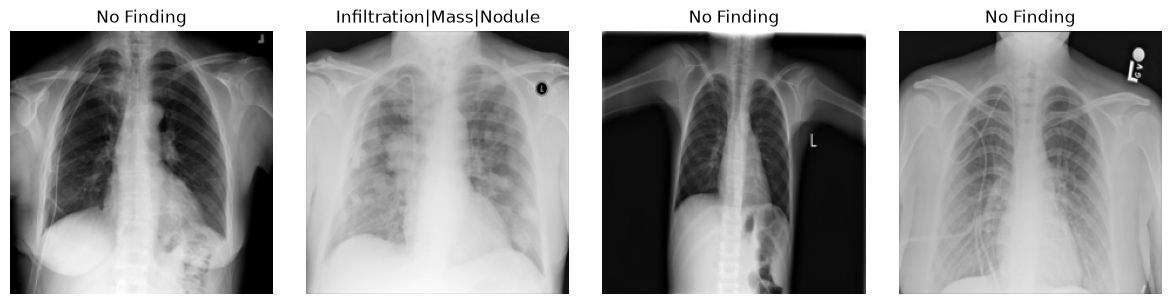

In [72]:
fig, axes = plt.subplots(1, 4, figsize = (12, 3))
for i, ax in enumerate(axes):
    img_name = sample_rows.iloc[i]['Image Index']
    img_path = os.path.join('images-224/images-224', img_name)
    raw_img = Image.open(img_path)
    
    ax.imshow(raw_img, cmap='gray')
    ax.set_title(sample_rows.iloc[i]['Finding Labels'])
    ax.axis('off')

plt.tight_layout()
plt.show()

In [73]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [74]:
device

device(type='cuda')

### Class imbalance assessment

Calculate negative-to-positive ratio for each of the 14 pathologies to fix the problem with unbalanced 
* positive - diseases
* negative - healthy cases

In [75]:
positive_weights = []
for disease in diseases:
    positive = train[disease].sum()
    negative = len(train) - positive
    positive_weights.append(negative / positive) 

In [79]:
#We transform the list into a tensor because pytorch requires this format for calculation
weights_tensor = torch.tensor(positive_weights, dtype = torch.float32)

In [78]:
print(weights_tensor)

tensor([ 38.9537,  43.8256,   7.3648, 473.5820,   4.6445,  18.6357,  16.6013,
          8.7559,  20.0455,  32.2454,  83.4595,  63.8561,  48.1754,  23.1573])


We observe a huge class imbalance across the 14 pathologies. We will apply these values in the loss function (BCEWithLogitsLoss) as positive weight (when there is а disease case). This ensures the model is penalized more heavily when it misses rare diseases.

##  Custom LoRA layer implementation

The original Vision Transformer has 86 million parameters trained on standard internet images, but it has never seen a medical X-ray. Instead of updating all 86 million numbers, we freeze the Google model. By using custom LoRA adapters, we add small trainable paths on the side. During training, the computer updates only these tiny adapter layers, tuning Google's vision specifically to detect complex lung pathologies.

I know that Hugging face has library *peft* for this. In a real job using the library is better and faster. However, I decided to write this code completely from scratch to learn exactly how LoRA really works.

In [82]:
class LoRALinear(nn.Module):
    def __init__(self, in_features, out_features, rank = 8, alpha = 16):
        
        super(LoRALinear, self).__init__()
        self.lora_A = nn.Linear(in_features, rank, bias = False)
        self.activation = nn.GELU()
        self.lora_B = nn.Linear(rank, out_features, bias = False)
        self.scaling = alpha / rank

        nn.init.kaiming_uniform_(self.lora_A.weight, a=5**0.5)
        nn.init.zeros_(self.lora_B.weight)

    
    def forward(self, x):
        return self.lora_B(self.activation(self.lora_A(x))) * self.scaling

* The 1st matrix *Lora_A* (down-projection) takes the base ViT hidden dimension (768 numbers) and shrinks it down to a very low rank (r = 8).  We use this bottleneck layout to reduce the number of trainable parameters to under 1%. This allows us to train the model fast, saves a big amounts of GPU memory, and prevents the model from forgetting what it already know. This matrix is then filled using Kaiming Uniform initialization which is a special way to set the starting weights to keep the learning process stable.
* Аctivation GELU is a non-linear activation function injected inside the bottleneck. This turns the standard linear LoRA path into a bottleneck adapter, allowing the model to extract complex pixel textures which is needed for fine medical data (X-ray shadows).
* The 2nd matrix *lora_B* (Up-projection) takes the 8 dimensions from the bottleneck and expands them back to the original 768 dimensions so they can be added back to the frozen model outputs. Then the matrix is initialized with zeros. This ensures that at step 0 of training, the adapter outputs are exactly 0, meaning it won't break pre-trained ImageNet knowledge.
* Scaling (alpha / rank) helps keep the training stable and smooth, even if we decide to change the rank size later.
